# 🤖 F1 2026 Chinese GP — Feature Engineering & Baseline Model
## Sprint Weekend — Notebook 02

**Sprint weekend có thêm data so với regular weekend:**
- `sq_*` — Sprint Qualifying pace & sectors
- `sprint_*` — Sprint race pace & result
- `sprint_pos_gained` — vị trí gained/lost trong Sprint

**Pipeline:**
1. Setup & Load
2. Feature Engineering
3. Feature Analysis & Selection
4. Model Training (LOO-CV)
5. Model Comparison
6. Feature Importance
7. Actual vs Predicted
8. Summary & Export


## 1. 📦 Setup & Load

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics         import mean_absolute_error, r2_score
from scipy.stats             import spearmanr

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('⚠️  pip install xgboost')

# ── Output folder ─────────────────────────────────────────────
FIG_DIR  = './figures_ml'
PROC_DIR = './processed'
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

def savefig(name):
    path = f'{FIG_DIR}/{name}'
    plt.savefig(path, dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
    print(f'  💾 {path}')

# ── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':'#0f0f0f', 'axes.facecolor'  :'#1a1a1a',
    'axes.edgecolor'  :'#2e2e2e', 'axes.labelcolor' :'#cccccc',
    'xtick.color'     :'#888888', 'ytick.color'     :'#888888',
    'text.color'      :'#dddddd', 'grid.color'      :'#2a2a2a',
    'grid.linestyle'  :'--',      'font.family'     :'monospace',
    'axes.titlesize'  :12,        'axes.labelsize'  :10,
    'figure.dpi'      :120,
})

TEAM_COLORS = {
    'Mercedes'      :'#00D7B6', 'Ferrari'       :'#E8002D',
    'McLaren'       :'#FF8000', 'Red Bull Racing':'#3671C6',
    'Aston Martin'  :'#229971', 'Alpine'        :'#FF87BC',
    'Williams'      :'#64C4FF', 'Haas F1 Team'  :'#B6BABD',
    'Audi'          :'#52E252', 'Racing Bulls'  :'#6692FF',
    'Cadillac'      :'#C8AA6E',
}

print(f'✅ Setup done | XGBoost: {HAS_XGB}')
print(f'   Figures  → {FIG_DIR}/')
print(f'   Processed→ {PROC_DIR}/')


✅ Setup done | XGBoost: True
   Figures  → ./figures_ml/
   Processed→ ./processed/


In [4]:
# ── Load df_drivers từ processed/ ────────────────────────────
df = pd.read_csv(f'{PROC_DIR}/df_drivers.csv')

# Restore bool columns
for col in ['eliminated_Q1','eliminated_Q2','reached_Q3','dnf','finished']:
    if col in df.columns:
        df[col] = df[col].astype(bool)

driver_team  = dict(zip(df['Driver'], df['Team']))
driver_color = {d: TEAM_COLORS.get(t,'#888888') for d,t in driver_team.items()}

print(f'✅ Loaded df_drivers: {df.shape}')
print(f'   Drivers: {sorted(df["Driver"].tolist())}')
print()
print('Null counts (non-zero):')
null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0]
for col, cnt in null_cols.items():
    print(f'  {col:35s}: {cnt}')


✅ Loaded df_drivers: (22, 57)
   Drivers: ['ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'BOT', 'COL', 'GAS', 'HAD', 'HAM', 'HUL', 'LAW', 'LEC', 'LIN', 'NOR', 'OCO', 'PER', 'PIA', 'RUS', 'SAI', 'STR', 'VER']

Null counts (non-zero):
  sq_laptime                         : 1
  sq_s1                              : 1
  sq_s2                              : 1
  sq_s3                              : 1
  sq_speed                           : 1
  sq_gap                             : 1
  Q2_s                               : 6
  Q3_s                               : 12
  pit_stops                          : 5
  first_pit                          : 5
  last_pit                           : 5
  race_fastest_s                     : 4
  race_fastest_speed                 : 4
  race_fastest_compound              : 4
  sq_sector_std                      : 1


## 2. ⚙️ Feature Engineering

Sprint weekend có **thêm data dự đoán** so với regular weekend:
`sprint_pos` và `sprint_pos_gained` là pre-race features vì Sprint diễn ra **trước** Race.

| Group | Features | Ghi chú |
|---|---|---|
| FP1 | laptime, gap, s1/s2/s3, speed | Baseline pace |
| Sprint Qualifying | laptime, gap, s1/s2/s3, speed | One-lap pace SQ |
| Sprint | laptime, gap, s1/s2/s3, speed | Race pace |
| Qualifying | laptime, gap, s1/s2/s3, speed | One-lap pace Q |
| Sprint Result | sprint_pos, sprint_pos_gained | **Pre-race predictor độc đáo** |
| Engineered | delta features, sector std, Q segment | Weekend progression |
| Starting | grid_pos | |


In [5]:
df_feat = df.copy()

# ── Engineered features mới ───────────────────────────────────

# Theoretical best lap (sum sectors)
df_feat['sq_theoretical_best']     = df_feat['sq_s1']     + df_feat['sq_s2']     + df_feat['sq_s3']
df_feat['sprint_theoretical_best'] = df_feat['sprint_s1'] + df_feat['sprint_s2'] + df_feat['sprint_s3']
df_feat['quali_theoretical_best']  = df_feat['quali_s1']  + df_feat['quali_s2']  + df_feat['quali_s3']

# Time loss vs theoretical best
df_feat['sq_time_loss']     = df_feat['sq_laptime']     - df_feat['sq_theoretical_best']
df_feat['sprint_time_loss'] = df_feat['sprint_laptime'] - df_feat['sprint_theoretical_best']
df_feat['quali_time_loss']  = df_feat['quali_laptime']  - df_feat['quali_theoretical_best']

# Speed differential giữa sessions
df_feat['sq_to_quali_speed']    = df_feat['quali_speed']  - df_feat['sq_speed']
df_feat['sprint_to_quali_speed']= df_feat['quali_speed']  - df_feat['sprint_speed']

# Rank trong từng session (1 = fastest)
for col, rank_col in [('sq_laptime','sq_rank'),('sprint_laptime','sprint_rank'),
                       ('quali_laptime','quali_rank')]:
    df_feat[rank_col] = df_feat[col].rank().astype(float)

# Rank change SQ → Qualifying
df_feat['rank_change_sq_to_quali'] = df_feat['quali_rank'] - df_feat['sq_rank']

# Sprint vs Qualifying rank change
df_feat['rank_change_sprint_to_quali'] = df_feat['quali_rank'] - df_feat['sprint_rank']

# Q segment reached (0=Q1 out, 1=Q2 out, 2=Q3)
df_feat['q_segment'] = (
    df_feat['reached_Q3'].astype(int) * 2 +
    df_feat['eliminated_Q2'].astype(int) * 1
)

# Sprint performance vs grid expectation
# (sprint_pos_gained đã có từ notebook 01)

# Sector vs field median (SQ)
for s in ['sq_s1','sq_s2','sq_s3']:
    med = df_feat[s].median()
    df_feat[f'{s}_vs_field'] = df_feat[s] - med   # âm = nhanh hơn field

# Qualifying sector vs field
for s in ['quali_s1','quali_s2','quali_s3']:
    med = df_feat[s].median()
    df_feat[f'{s}_vs_field'] = df_feat[s] - med

print('✅ Feature engineering done')
print(f'   Tổng columns: {len(df_feat.columns)}')
print()

new_feats = [
    'sq_theoretical_best','sprint_theoretical_best','quali_theoretical_best',
    'sq_time_loss','sprint_time_loss','quali_time_loss',
    'sq_to_quali_speed','sprint_to_quali_speed',
    'sq_rank','sprint_rank','quali_rank',
    'rank_change_sq_to_quali','rank_change_sprint_to_quali',
    'q_segment',
    'sq_s1_vs_field','sq_s2_vs_field','sq_s3_vs_field',
    'quali_s1_vs_field','quali_s2_vs_field','quali_s3_vs_field',
]
print('Features mới:')
print(df_feat[['Driver'] + new_feats[:8]].to_string(index=False))


✅ Feature engineering done
   Tổng columns: 77

Features mới:
Driver  sq_theoretical_best  sprint_theoretical_best  quali_theoretical_best  sq_time_loss  sprint_time_loss  quali_time_loss  sq_to_quali_speed  sprint_to_quali_speed
   ANT               91.809                   94.760                  92.064  0.000000e+00      1.421085e-14    -1.421085e-14               -4.0                  -23.0
   RUS               91.520                   95.101                  92.286  0.000000e+00      0.000000e+00     0.000000e+00               -4.0                  -21.0
   HAM               92.161                   94.926                  92.415  0.000000e+00      0.000000e+00     1.421085e-14               -9.0                  -17.0
   LEC               92.528                   94.753                  92.428  1.421085e-14      0.000000e+00     0.000000e+00                4.0                   -4.0
   BEA               93.409                   97.374                  93.197  0.000000e+00      0.

## 3. 🔍 Feature Analysis & Selection

In [6]:
# ── Định nghĩa feature set ────────────────────────────────────
#
# RULE: Chỉ dùng features CÓ TRƯỚC race (pre-race)
# Sprint diễn ra trước Race → sprint_pos, sprint_pos_gained là LEGAL
# KHÔNG dùng: race_laps, positions_gained, pit_stops (biết sau race)
#
FEATURE_COLS = [
    # FP1
    'fp1_laptime', 'fp1_gap',

    # Sprint Qualifying
    'sq_laptime', 'sq_gap',
    'sq_s1', 'sq_s2', 'sq_s3', 'sq_speed',
    'sq_sector_std', 'sq_theoretical_best',
    'sq_s1_vs_field', 'sq_s2_vs_field', 'sq_s3_vs_field',

    # Sprint race
    'sprint_laptime', 'sprint_gap', 'sprint_speed',
    'sprint_sector_std', 'sprint_theoretical_best',
    'sprint_pos',           # ← pre-race predictor (Sprint diễn ra trước Race)
    'sprint_pos_gained',    # ← positions gained trong Sprint

    # Qualifying
    'quali_laptime', 'quali_gap', 'quali_speed',
    'quali_s1', 'quali_s2', 'quali_s3',
    'quali_theoretical_best', 'quali_time_loss',
    'quali_s1_vs_field', 'quali_s2_vs_field', 'quali_s3_vs_field',
    'q_segment',

    # Weekend progression
    'fp1_to_sq_delta',
    'sq_to_quali_delta',
    'quali_vs_sprint',
    'rank_change_sq_to_quali',
    'rank_change_sprint_to_quali',
    'sq_to_quali_speed',

    # Starting position
    'grid_pos',
]

TARGET = 'race_pos'

df_ml = df_feat.dropna(subset=FEATURE_COLS + [TARGET]).reset_index(drop=True)
df_ml[TARGET] = df_ml[TARGET].astype(int)

X = df_ml[FEATURE_COLS].copy()
y = df_ml[TARGET].copy()

print(f'✅ ML Dataset: {X.shape[0]} drivers × {X.shape[1]} features')
print(f'   Target: P{y.min()} – P{y.max()}')
print()
print(df_ml[['Driver','Team','grid_pos','sprint_pos','race_pos','race_status']].to_string(index=False))


✅ ML Dataset: 21 drivers × 39 features
   Target: P1 – P22

Driver            Team  grid_pos  sprint_pos  race_pos   race_status
   ANT        Mercedes       1.0         5.0         1      Finished
   RUS        Mercedes       2.0         1.0         2      Finished
   HAM         Ferrari       3.0         3.0         3      Finished
   LEC         Ferrari       4.0         2.0         4      Finished
   BEA    Haas F1 Team      10.0         8.0         5      Finished
   GAS          Alpine       7.0        11.0         6      Finished
   LAW    Racing Bulls      14.0         7.0         7      Finished
   HAD Red Bull Racing       9.0        15.0         8      Finished
   SAI        Williams      17.0        12.0         9        Lapped
   COL          Alpine      12.0        14.0        10        Lapped
   HUL            Audi      11.0        20.0        11        Lapped
   LIN    Racing Bulls      15.0        22.0        12        Lapped
   BOT        Cadillac      19.0        21.

  💾 ./figures_ml/01_feature_correlation.png


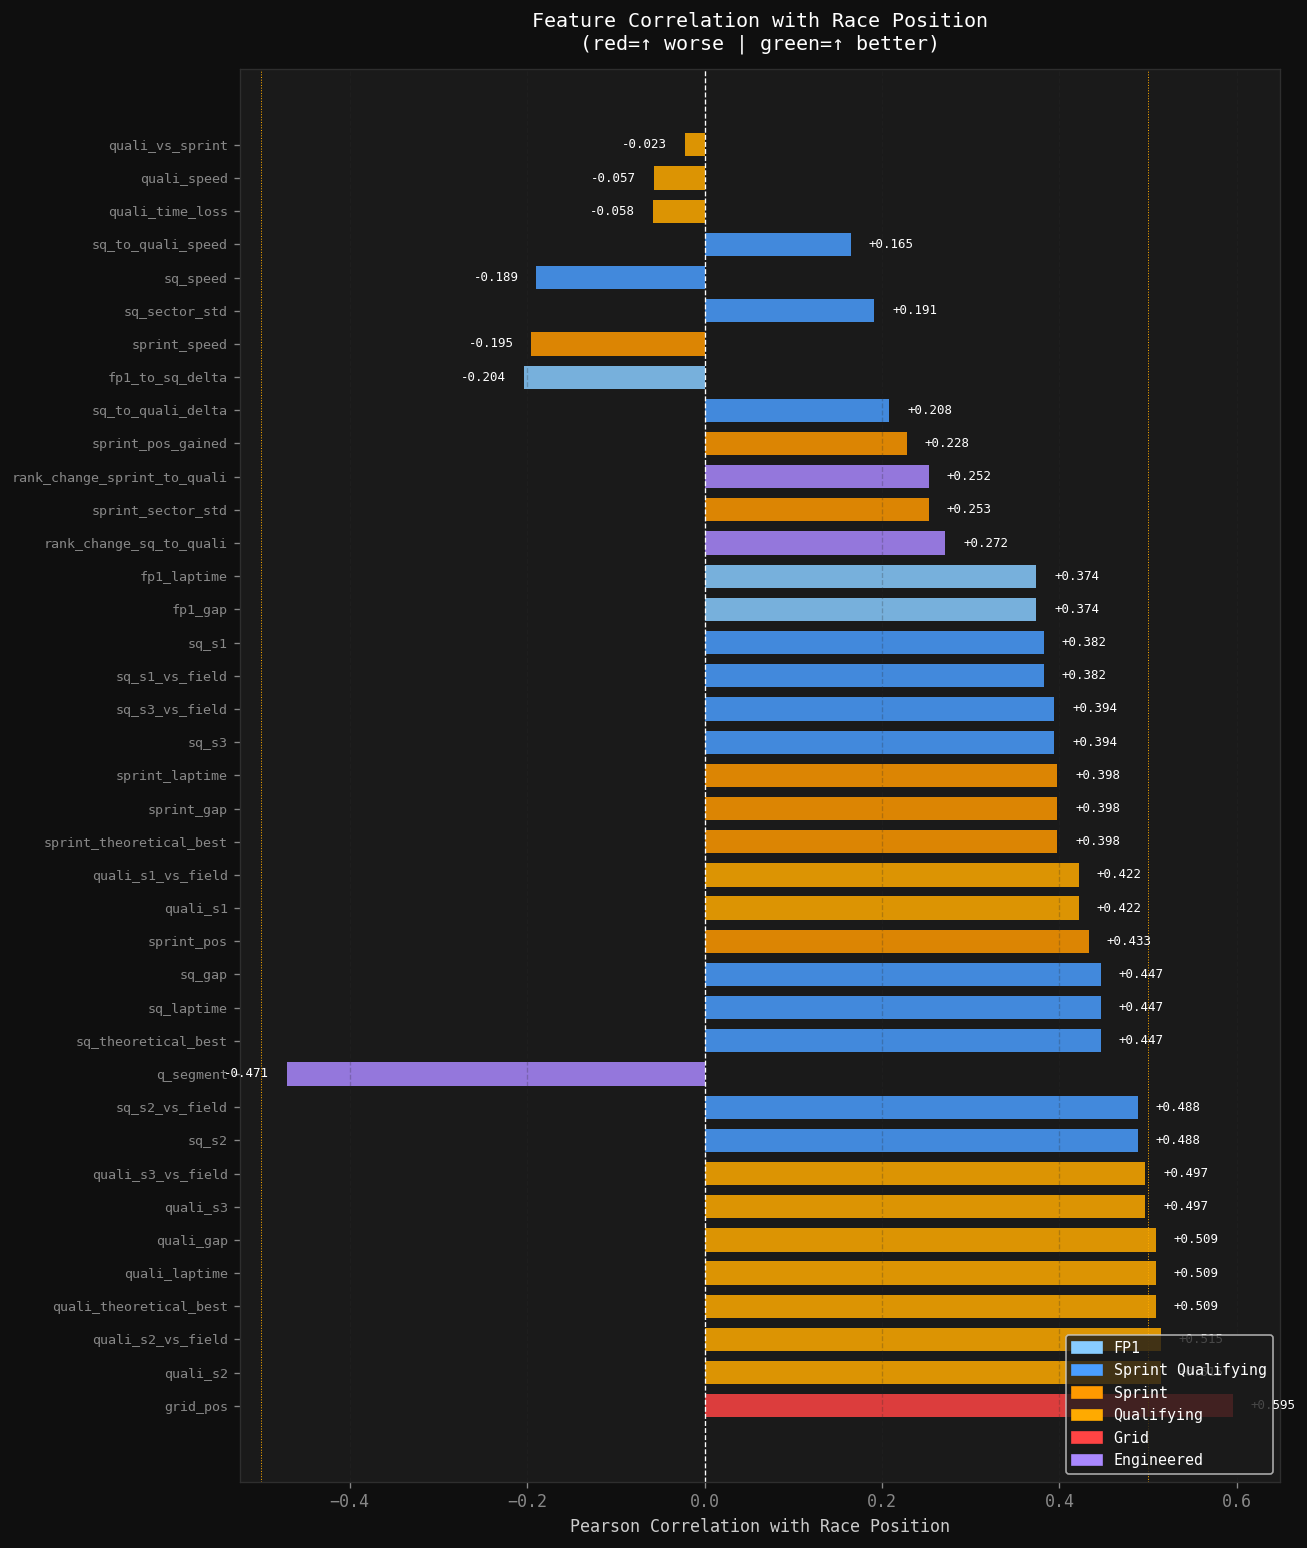

Top 12 features:
  grid_pos                           : +0.595  ██████████████
  quali_s2                           : +0.515  ████████████
  quali_s2_vs_field                  : +0.515  ████████████
  quali_theoretical_best             : +0.509  ████████████
  quali_laptime                      : +0.509  ████████████
  quali_gap                          : +0.509  ████████████
  quali_s3                           : +0.497  ████████████
  quali_s3_vs_field                  : +0.497  ████████████
  sq_s2                              : +0.488  ████████████
  sq_s2_vs_field                     : +0.488  ████████████
  q_segment                          : -0.471  ███████████
  sq_theoretical_best                : +0.447  ███████████


In [7]:
# ── Correlation với race_pos ──────────────────────────────────
corr_data = X.copy()
corr_data[TARGET] = y
corr_series = corr_data.corrwith(corr_data[TARGET]).drop(TARGET)
corr_series = corr_series.dropna().sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(11, 13))
fig.patch.set_facecolor('#0f0f0f')

def feat_group_color(f):
    if f.startswith('fp1'):     return '#88ccff'
    if f.startswith('sq'):      return '#4a9eff'
    if f.startswith('sprint'):  return '#ff9900'
    if f.startswith('quali'):   return '#ffaa00'
    if f in ('grid_pos',):      return '#ff4444'
    return '#aa88ff'

colors = [feat_group_color(f) for f in corr_series.index]
ax.barh(range(len(corr_series)), corr_series.values, color=colors, alpha=0.85, height=0.7)
ax.set_yticks(range(len(corr_series)))
ax.set_yticklabels(corr_series.index, fontsize=8)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.axvline( 0.5, color='#ffaa00', linewidth=0.6, linestyle=':')
ax.axvline(-0.5, color='#ffaa00', linewidth=0.6, linestyle=':')
for i,(feat,val) in enumerate(corr_series.items()):
    ax.text(val+(0.02 if val>=0 else -0.02), i, f'{val:+.3f}',
            va='center', ha='left' if val>=0 else 'right', fontsize=7.5, color='white')
ax.set_xlabel('Pearson Correlation with Race Position')
ax.set_title('Feature Correlation with Race Position\n'
             '(red=↑ worse | green=↑ better)',
             color='white', pad=12)
ax.grid(axis='x', alpha=0.25)

legend_items = [
    mpatches.Patch(color='#88ccff', label='FP1'),
    mpatches.Patch(color='#4a9eff', label='Sprint Qualifying'),
    mpatches.Patch(color='#ff9900', label='Sprint'),
    mpatches.Patch(color='#ffaa00', label='Qualifying'),
    mpatches.Patch(color='#ff4444', label='Grid'),
    mpatches.Patch(color='#aa88ff', label='Engineered'),
]
ax.legend(handles=legend_items, loc='lower right',
          facecolor='#1a1a1a', labelcolor='white', fontsize=9)

plt.tight_layout(); savefig('01_feature_correlation.png'); plt.show()

print('Top 12 features:')
for feat, val in corr_series.head(12).items():
    bar = '█' * int(abs(val)*25)
    print(f'  {feat:35s}: {val:+.3f}  {bar}')


  💾 ./figures_ml/02_top_features_scatter.png


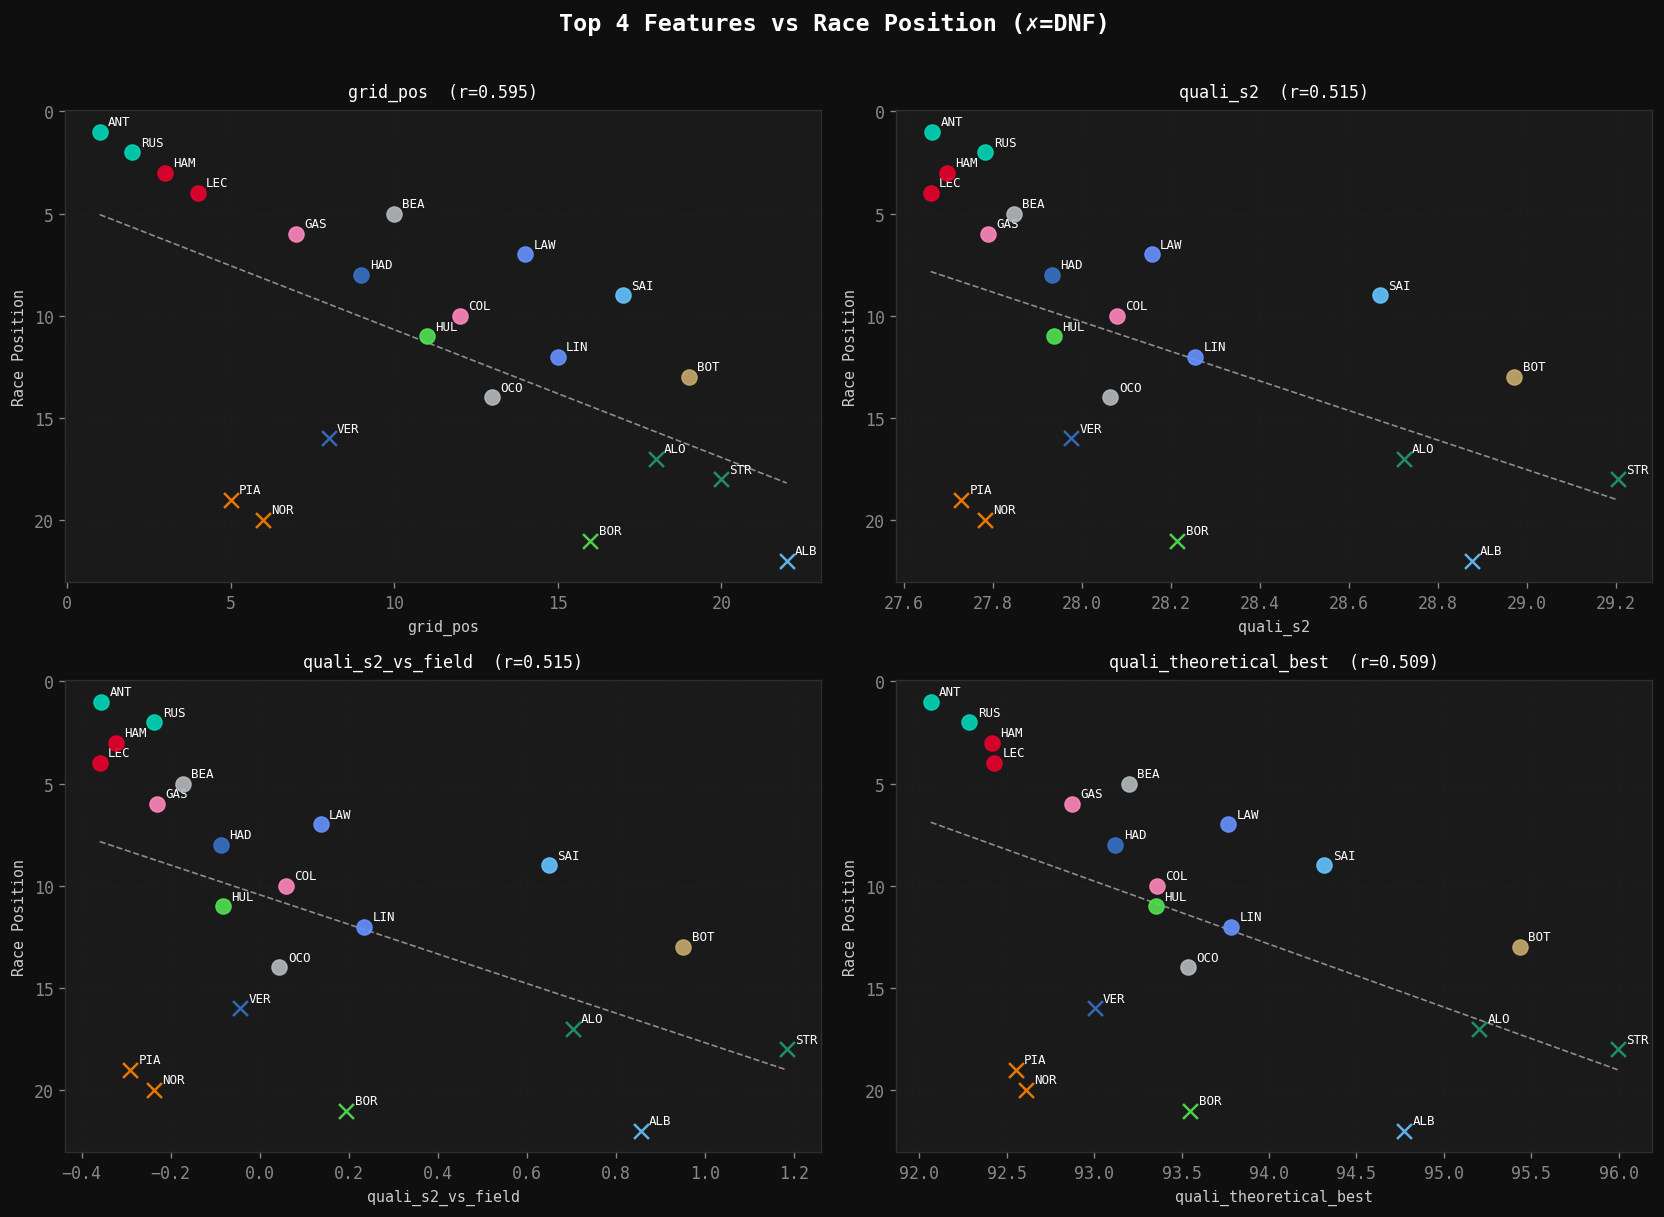

In [8]:
# ── Top 4 features scatter ────────────────────────────────────
top4 = corr_series.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

for ax, feat in zip(axes, top4):
    valid = df_ml.dropna(subset=[feat, TARGET])
    for _, row in valid.iterrows():
        c = TEAM_COLORS.get(row['Team'],'#888888')
        m = 'x' if row['dnf'] else 'o'
        ax.scatter(row[feat], row[TARGET], color=c, s=80, marker=m, alpha=0.9, zorder=5)
        ax.annotate(row['Driver'], (row[feat], row[TARGET]),
                    textcoords='offset points', xytext=(5,4), fontsize=7.5, color='white')
    if len(valid)>2:
        z  = np.polyfit(valid[feat], valid[TARGET], 1)
        xl = np.linspace(valid[feat].min(), valid[feat].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), '--', color='white', linewidth=1, alpha=0.5)
        r = valid[[feat,TARGET]].corr().iloc[0,1]
        ax.set_title(f'{feat}  (r={r:.3f})', color='white', fontsize=10, pad=8)
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel('Race Position', fontsize=9)
    ax.invert_yaxis(); ax.grid(alpha=0.2)

plt.suptitle('Top 4 Features vs Race Position (✗=DNF)',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('02_top_features_scatter.png'); plt.show()


## 4. 🤖 Model Training — LOO-CV

**Leave-One-Out CV** phù hợp với n=20 drivers.

**Thử 2 feature set để so sánh:**
- **Set A** — Full (tất cả 37 features kể cả sprint_pos)
- **Set B** — No Sprint Result (bỏ sprint_pos, sprint_pos_gained — giả lập dự đoán trước Sprint)


In [9]:
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Feature set B: bỏ sprint result features
FEATURE_COLS_B = [f for f in FEATURE_COLS
                  if f not in ('sprint_pos','sprint_pos_gained')]
X_b        = df_ml[FEATURE_COLS_B].copy()
X_scaled_b = pd.DataFrame(
    StandardScaler().fit_transform(X_b), columns=X_b.columns)

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge (α=1)'       : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(
                            n_estimators=200, max_depth=4,
                            min_samples_leaf=2, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(
                            n_estimators=100, max_depth=3,
                            learning_rate=0.1, random_state=42),
}
if HAS_XGB:
    models['XGBoost'] = XGBRegressor(
        n_estimators=100, max_depth=3,
        learning_rate=0.1, random_state=42, verbosity=0)

loo      = LeaveOneOut()
results  = {}
all_preds= {}

print('Training — LOO-CV...\n')
print(f'{"Model":22s} | {"Set":3s} | MAE   | R²     | Spearman | ±2    | ±3')
print('─'*72)

for feat_set, X_use, set_label in [
    (FEATURE_COLS,   X_scaled,   'A'),
    (FEATURE_COLS_B, X_scaled_b, 'B'),
]:
    for name, model in models.items():
        oof = np.zeros(len(y))
        for tr, te in loo.split(X_use):
            model.fit(X_use.iloc[tr], y.iloc[tr])
            oof[te] = model.predict(X_use.iloc[te])

        mae    = mean_absolute_error(y, oof)
        r2     = r2_score(y, oof)
        sp, p  = spearmanr(y, oof)
        w2     = np.mean(np.abs(y-oof) <= 2)
        w3     = np.mean(np.abs(y-oof) <= 3)

        key = f'{name} [{set_label}]'
        results[key]    = {'MAE':round(mae,3),'R²':round(r2,3),
                           'Spearman':round(sp,3),'p-value':round(p,4),
                           'Within±2':f'{w2:.0%}','Within±3':f'{w3:.0%}',
                           'FeatureSet':set_label}
        all_preds[key]  = oof.copy()
        print(f'  {name:22s} | {set_label}   | {mae:.2f}  | {r2:.3f}  | {sp:.3f}    | {w2:.0%}   | {w3:.0%}')

    # Retrain full cho feature importance
    for name, model in models.items():
        model.fit(X_use, y)

    print()

best_name = max(
    {k:v for k,v in results.items() if v['FeatureSet']=='A'},
    key=lambda k: results[k]['Spearman']
)
print(f'\n✅ Best model (Set A, Spearman): {best_name}')


Training — LOO-CV...

Model                  | Set | MAE   | R²     | Spearman | ±2    | ±3
────────────────────────────────────────────────────────────────────────
  Linear Regression      | A   | 48.75  | -440.890  | 0.165    | 0%   | 0%
  Ridge (α=1)            | A   | 8.02  | -0.971  | 0.131    | 14%   | 14%
  Random Forest          | A   | 5.46  | -0.024  | 0.125    | 29%   | 33%
  Gradient Boosting      | A   | 6.03  | -0.186  | 0.242    | 14%   | 29%
  XGBoost                | A   | 5.59  | -0.164  | 0.292    | 33%   | 33%

  Linear Regression      | B   | 10.74  | -4.454  | 0.544    | 19%   | 19%
  Ridge (α=1)            | B   | 8.47  | -1.346  | -0.100    | 19%   | 19%
  Random Forest          | B   | 5.55  | -0.040  | 0.110    | 19%   | 33%
  Gradient Boosting      | B   | 5.86  | -0.176  | 0.214    | 19%   | 38%
  XGBoost                | B   | 5.93  | -0.328  | 0.199    | 33%   | 33%


✅ Best model (Set A, Spearman): XGBoost [A]


## 5. 📊 Model Comparison

MODEL COMPARISON:
                          MAE      R² Spearman p-value Within±2 Within±3 FeatureSet
Linear Regression [A]   48.75 -440.89    0.165  0.4749       0%       0%          A
Ridge (α=1) [A]          8.02  -0.971    0.131  0.5709      14%      14%          A
Random Forest [A]        5.46  -0.024    0.125  0.5903      29%      33%          A
Gradient Boosting [A]   6.034  -0.186    0.242  0.2915      14%      29%          A
XGBoost [A]             5.589  -0.164    0.292  0.1987      33%      33%          A
Linear Regression [B]  10.742  -4.454    0.544  0.0108      19%      19%          B
Ridge (α=1) [B]         8.467  -1.346     -0.1  0.6663      19%      19%          B
Random Forest [B]       5.554   -0.04     0.11  0.6338      19%      33%          B
Gradient Boosting [B]   5.861  -0.176    0.214  0.3509      19%      38%          B
XGBoost [B]             5.925  -0.328    0.199  0.3879      33%      33%          B
  💾 ./figures_ml/03_model_comparison_AB.png


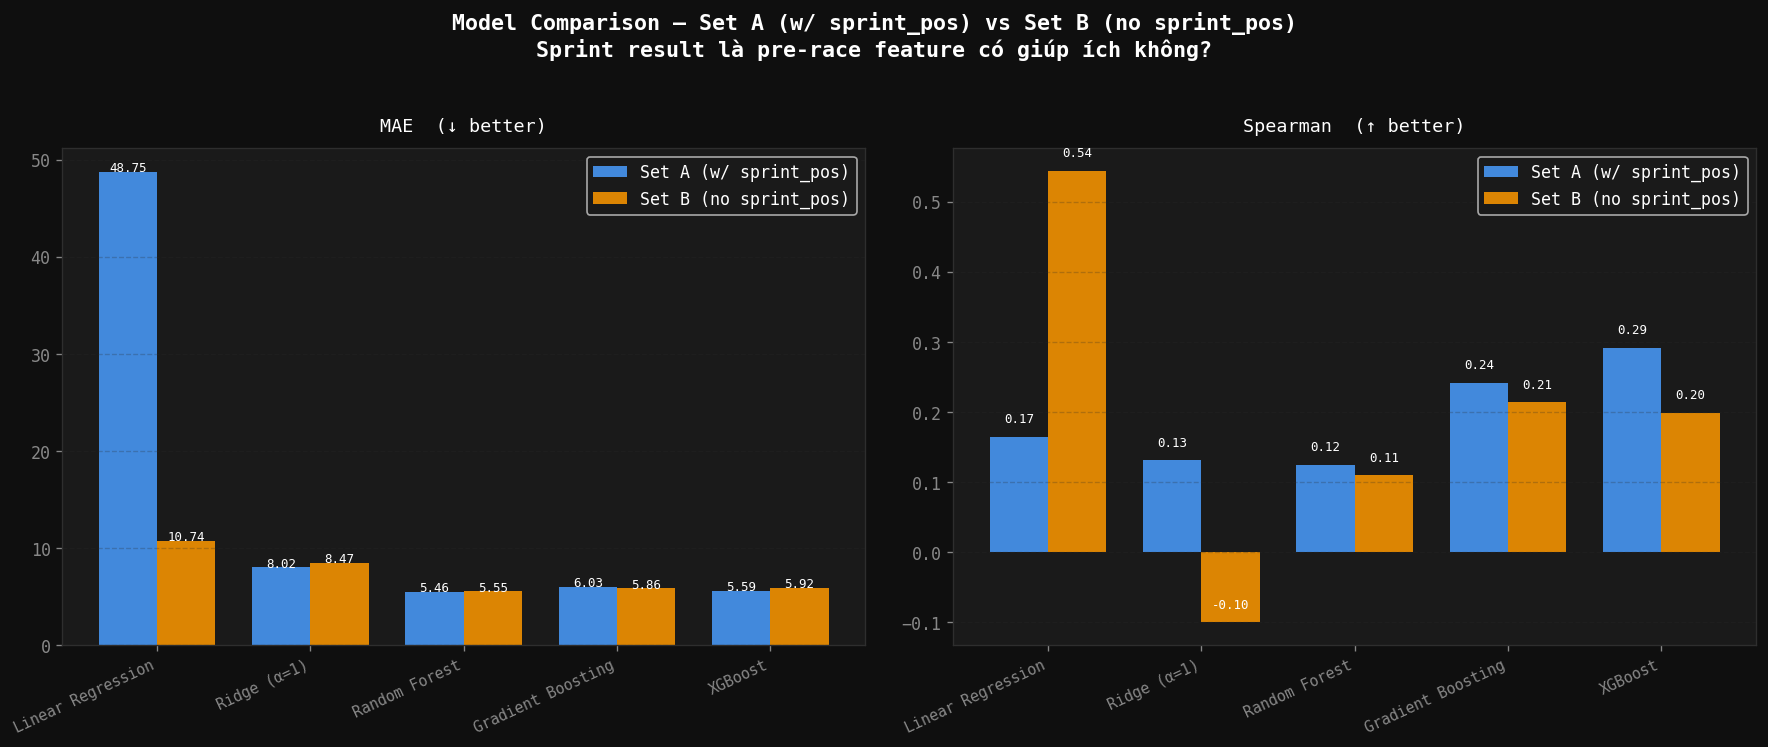

In [10]:
results_df = pd.DataFrame(results).T
print('MODEL COMPARISON:')
print(results_df.to_string())

# ── Visual: Set A vs Set B per model ─────────────────────────
model_names = list(models.keys())
mae_A   = [results[f'{m} [A]']['MAE']      for m in model_names]
mae_B   = [results[f'{m} [B]']['MAE']      for m in model_names]
spear_A = [results[f'{m} [A]']['Spearman'] for m in model_names]
spear_B = [results[f'{m} [B]']['Spearman'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0f0f0f')

x = np.arange(len(model_names))
w = 0.38

for ax, vals_A, vals_B, metric, note in [
    (axes[0], mae_A,   mae_B,   'MAE',      '↓ better'),
    (axes[1], spear_A, spear_B, 'Spearman', '↑ better'),
]:
    ax.bar(x-w/2, vals_A, width=w, color='#4a9eff', alpha=0.85, label='Set A (w/ sprint_pos)')
    ax.bar(x+w/2, vals_B, width=w, color='#ff9900', alpha=0.85, label='Set B (no sprint_pos)')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'{metric}  ({note})', color='white', fontsize=11, pad=10)
    ax.legend(facecolor='#1a1a1a', labelcolor='white')
    ax.grid(axis='y', alpha=0.25)
    for i,(a,b) in enumerate(zip(vals_A,vals_B)):
        ax.text(i-w/2, a+0.02, f'{a:.2f}', ha='center', fontsize=7.5, color='white')
        ax.text(i+w/2, b+0.02, f'{b:.2f}', ha='center', fontsize=7.5, color='white')

plt.suptitle('Model Comparison — Set A (w/ sprint_pos) vs Set B (no sprint_pos)\n'
             'Sprint result là pre-race feature có giúp ích không?',
             color='white', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(); savefig('03_model_comparison_AB.png'); plt.show()


  💾 ./figures_ml/04_error_per_driver.png


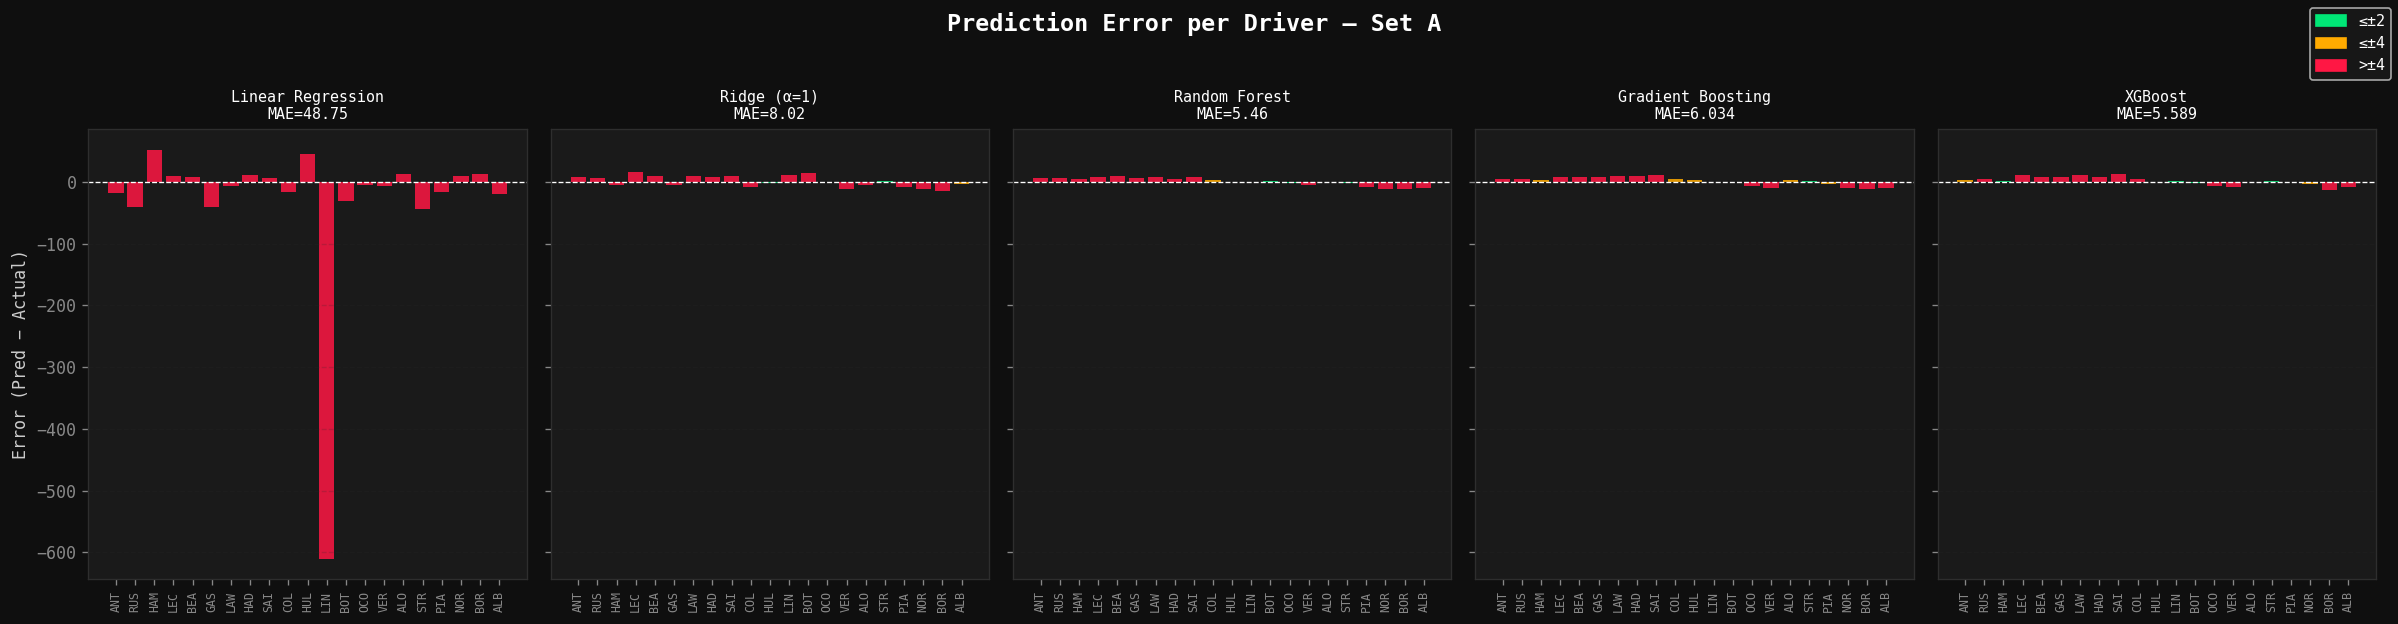

In [11]:
# ── Error distribution per model (Set A) ─────────────────────
setA_keys = [k for k in all_preds if '[A]' in k]

fig, axes = plt.subplots(1, len(setA_keys), figsize=(4*len(setA_keys), 5), sharey=True)
fig.patch.set_facecolor('#0f0f0f')

for ax, key in zip(axes, setA_keys):
    errors = all_preds[key] - y.values
    colors = ['#00e676' if abs(e)<=2 else '#ffaa00' if abs(e)<=4 else '#ff1744'
              for e in errors]
    ax.bar(range(len(errors)), errors, color=colors, alpha=0.85)
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(errors)))
    ax.set_xticklabels(df_ml['Driver'].values, rotation=90, fontsize=7)
    name_short = key.replace(' [A]','')
    ax.set_title(f'{name_short}\nMAE={results[key]["MAE"]}',
                 color='white', fontsize=9, pad=6)
    ax.grid(axis='y', alpha=0.2)

axes[0].set_ylabel('Error (Pred − Actual)')
fig.legend(handles=[
    mpatches.Patch(color='#00e676', label='≤±2'),
    mpatches.Patch(color='#ffaa00', label='≤±4'),
    mpatches.Patch(color='#ff1744', label='>±4'),
], loc='upper right', facecolor='#1a1a1a', labelcolor='white', fontsize=9)
plt.suptitle('Prediction Error per Driver — Set A',
             color='white', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); savefig('04_error_per_driver.png'); plt.show()


## 6. 🎯 Feature Importance

  💾 ./figures_ml/05_feature_importance.png


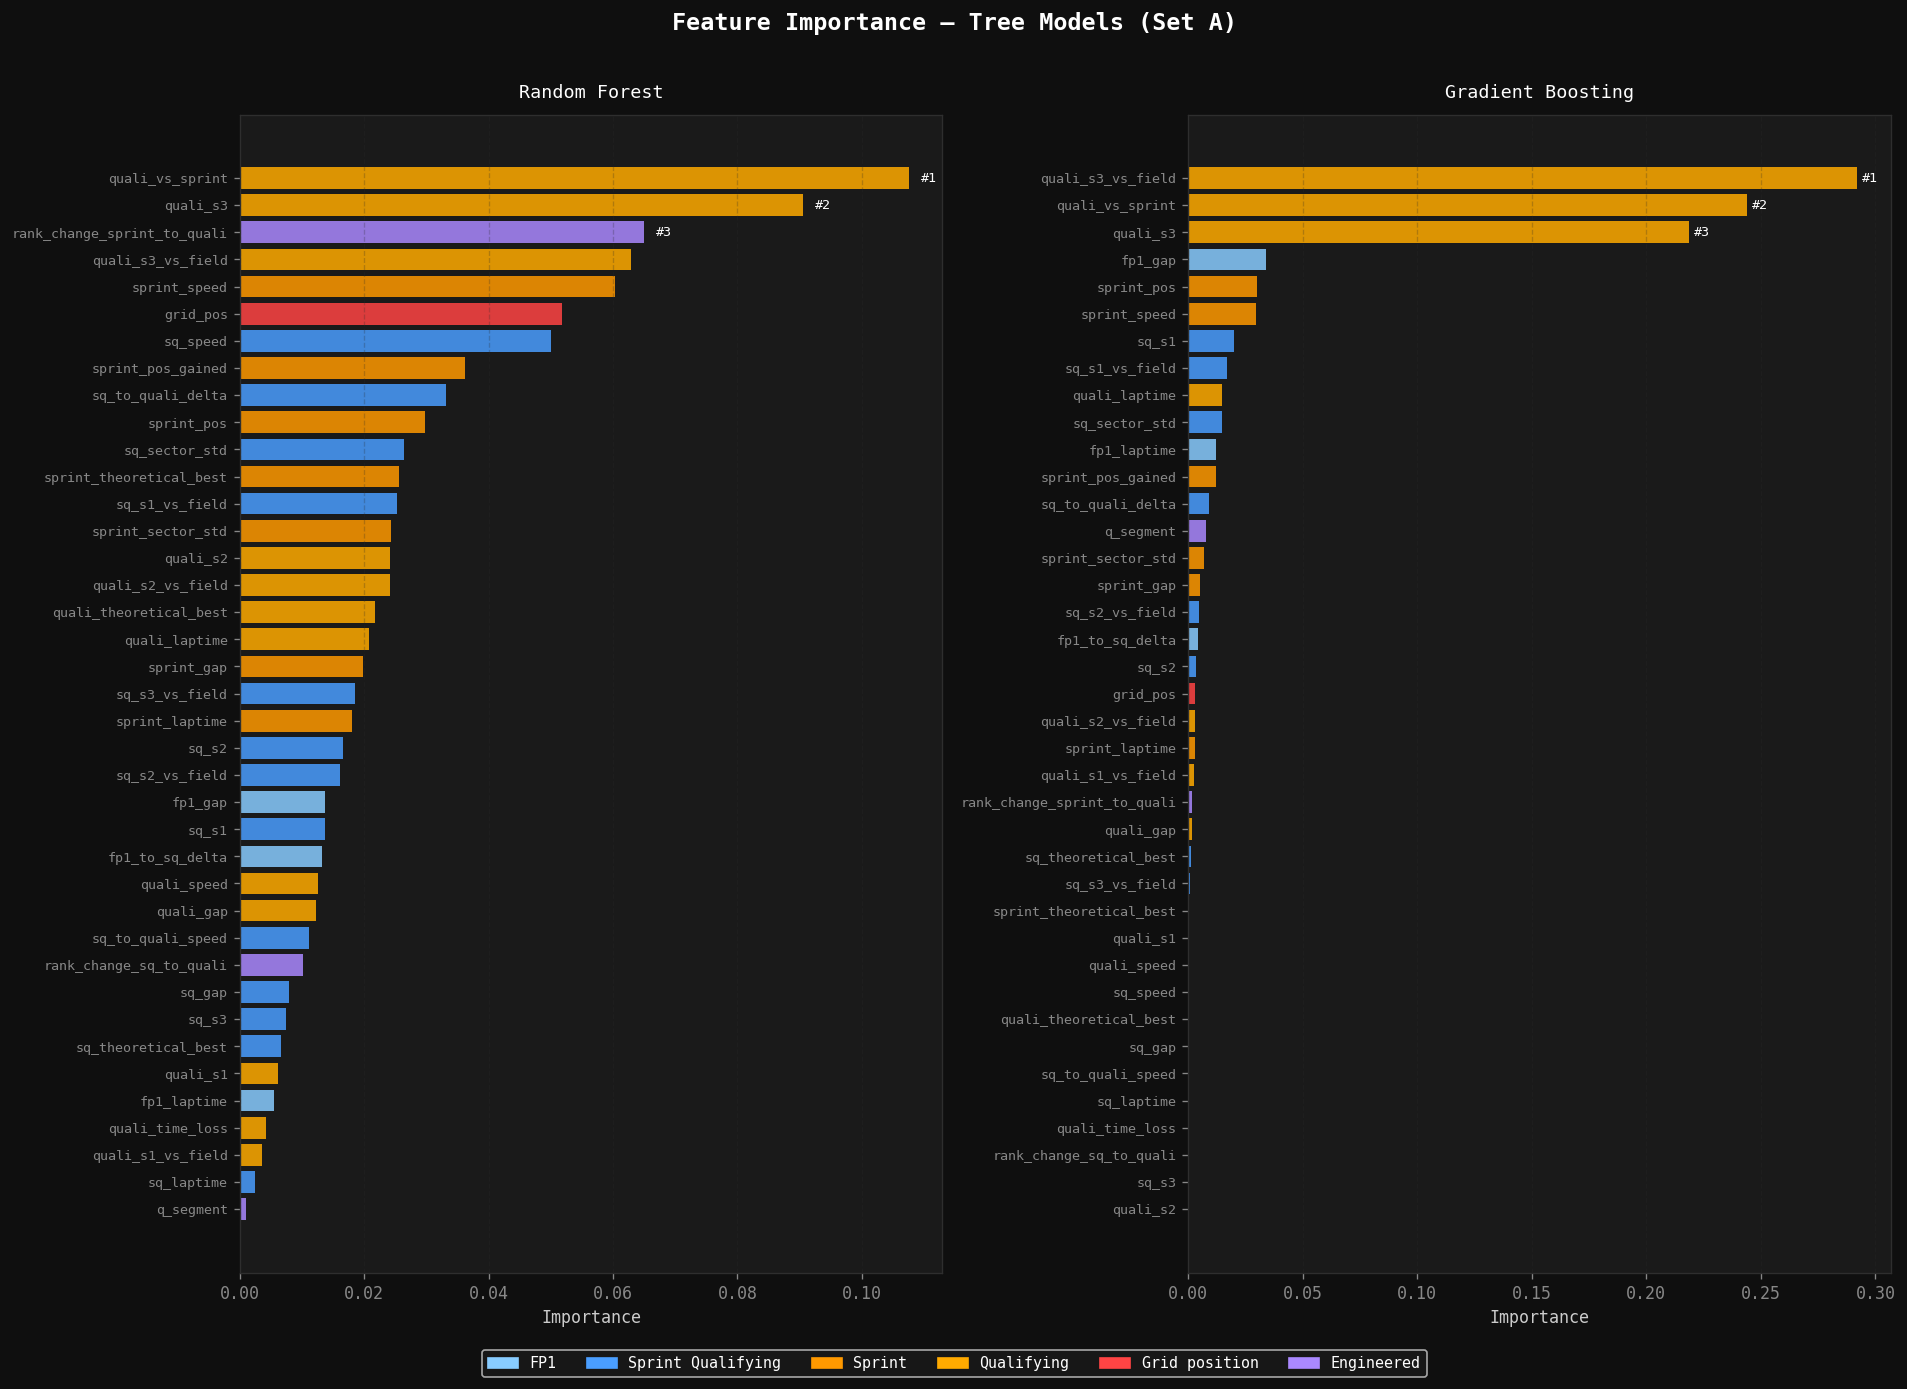

Top 10 features (Random Forest):
   1. quali_vs_sprint                    : 0.108  ██████████
   2. quali_s3                           : 0.090  █████████
   3. rank_change_sprint_to_quali        : 0.065  ██████
   4. quali_s3_vs_field                  : 0.063  ██████
   5. sprint_speed                       : 0.060  ██████
   6. grid_pos                           : 0.052  █████
   7. sq_speed                           : 0.050  █████
   8. sprint_pos_gained                  : 0.036  ███
   9. sq_to_quali_delta                  : 0.033  ███
  10. sprint_pos                         : 0.030  ██


In [12]:
# Retrain RF & GB trên full data (Set A)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=4,
                                  min_samples_leaf=2, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                      learning_rate=0.1, random_state=42)
rf_model.fit(X_scaled, y)
gb_model.fit(X_scaled, y)

def feat_color(f):
    if f.startswith('fp1'):    return '#88ccff'
    if f.startswith('sq'):     return '#4a9eff'
    if f.startswith('sprint'): return '#ff9900'
    if f.startswith('quali'):  return '#ffaa00'
    if f == 'grid_pos':        return '#ff4444'
    return '#aa88ff'

fig, axes = plt.subplots(1, 2, figsize=(16, 11))
fig.patch.set_facecolor('#0f0f0f')

for ax, (name, model) in zip(axes, [('Random Forest', rf_model),
                                      ('Gradient Boosting', gb_model)]):
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
    ax.barh(range(len(imp)), imp.values,
            color=[feat_color(f) for f in imp.index], alpha=0.85)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index, fontsize=8)
    ax.set_title(name, color='white', fontsize=11, pad=10)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.25)
    for rank, (feat, val) in enumerate(imp.sort_values(ascending=False).head(3).items()):
        idx = list(imp.index).index(feat)
        ax.text(val+0.002, idx, f'#{rank+1}', va='center', fontsize=8, color='white')

legend_items = [
    mpatches.Patch(color='#88ccff', label='FP1'),
    mpatches.Patch(color='#4a9eff', label='Sprint Qualifying'),
    mpatches.Patch(color='#ff9900', label='Sprint'),
    mpatches.Patch(color='#ffaa00', label='Qualifying'),
    mpatches.Patch(color='#ff4444', label='Grid position'),
    mpatches.Patch(color='#aa88ff', label='Engineered'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=6,
           facecolor='#1a1a1a', labelcolor='white', fontsize=9,
           bbox_to_anchor=(0.5,-0.03))

plt.suptitle('Feature Importance — Tree Models (Set A)',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('05_feature_importance.png'); plt.show()

rf_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print('Top 10 features (Random Forest):')
for i,(feat,val) in enumerate(rf_imp.head(10).items(),1):
    bar = '█' * int(val*100)
    print(f'  {i:2d}. {feat:35s}: {val:.3f}  {bar}')


  💾 ./figures_ml/06_ridge_coefficients.png


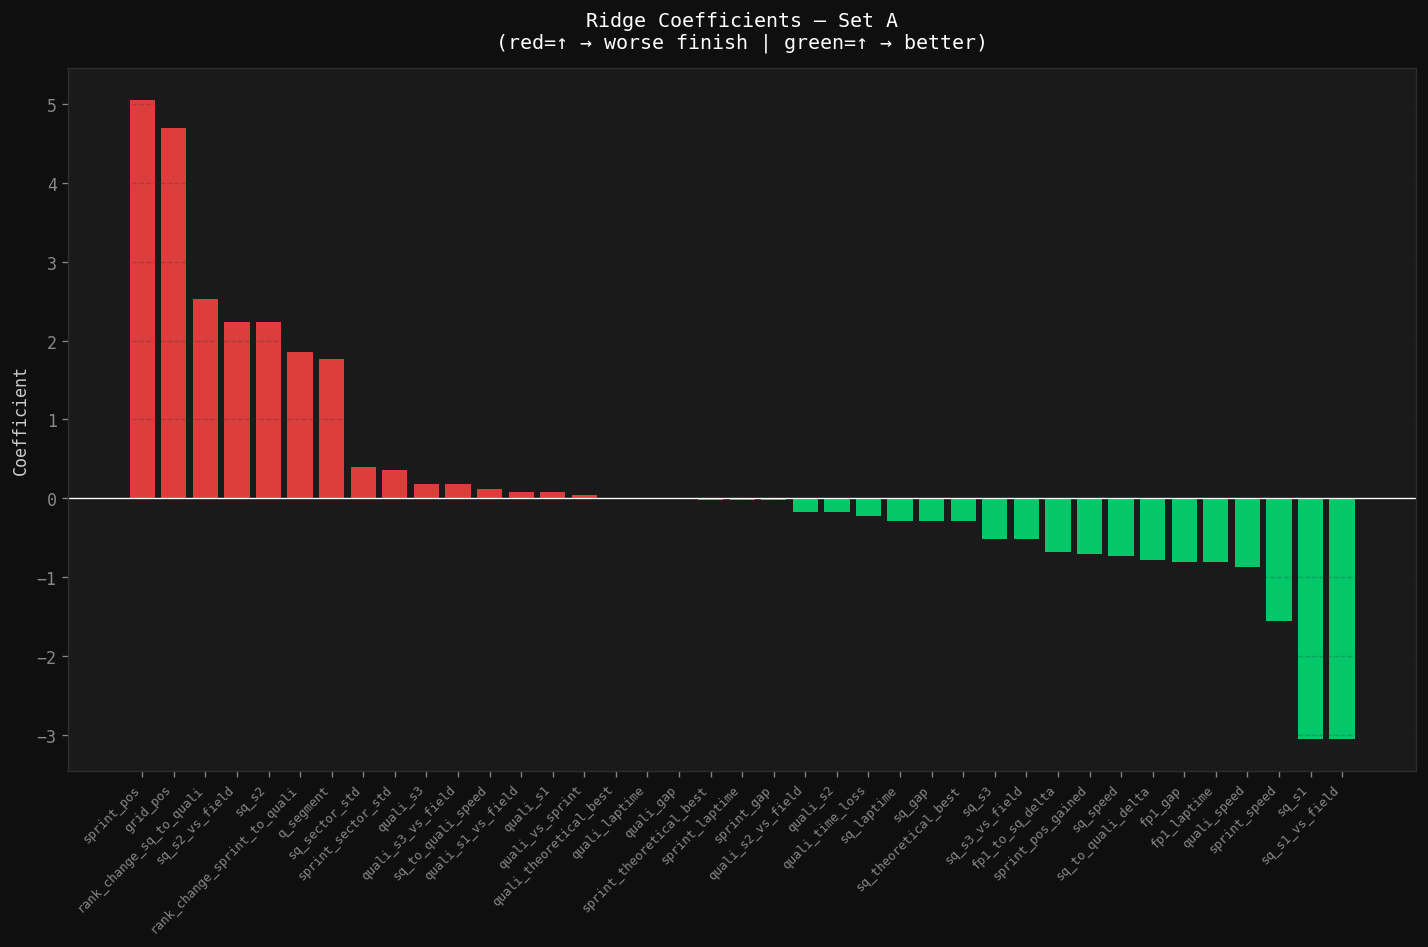

In [13]:
# ── Ridge coefficients ────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y)
coef = pd.Series(ridge.coef_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0f0f0f')
bar_c = ['#ff4444' if v>0 else '#00e676' for v in coef.values]
ax.bar(range(len(coef)), coef.values, color=bar_c, alpha=0.85)
ax.set_xticks(range(len(coef)))
ax.set_xticklabels(coef.index, rotation=45, ha='right', fontsize=7.5)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Ridge Coefficients — Set A\n(red=↑ → worse finish | green=↑ → better)',
             color='white', pad=12)
ax.set_ylabel('Coefficient')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout(); savefig('06_ridge_coefficients.png'); plt.show()


## 7. 🏁 Actual vs Predicted

  💾 ./figures_ml/07_actual_vs_predicted.png


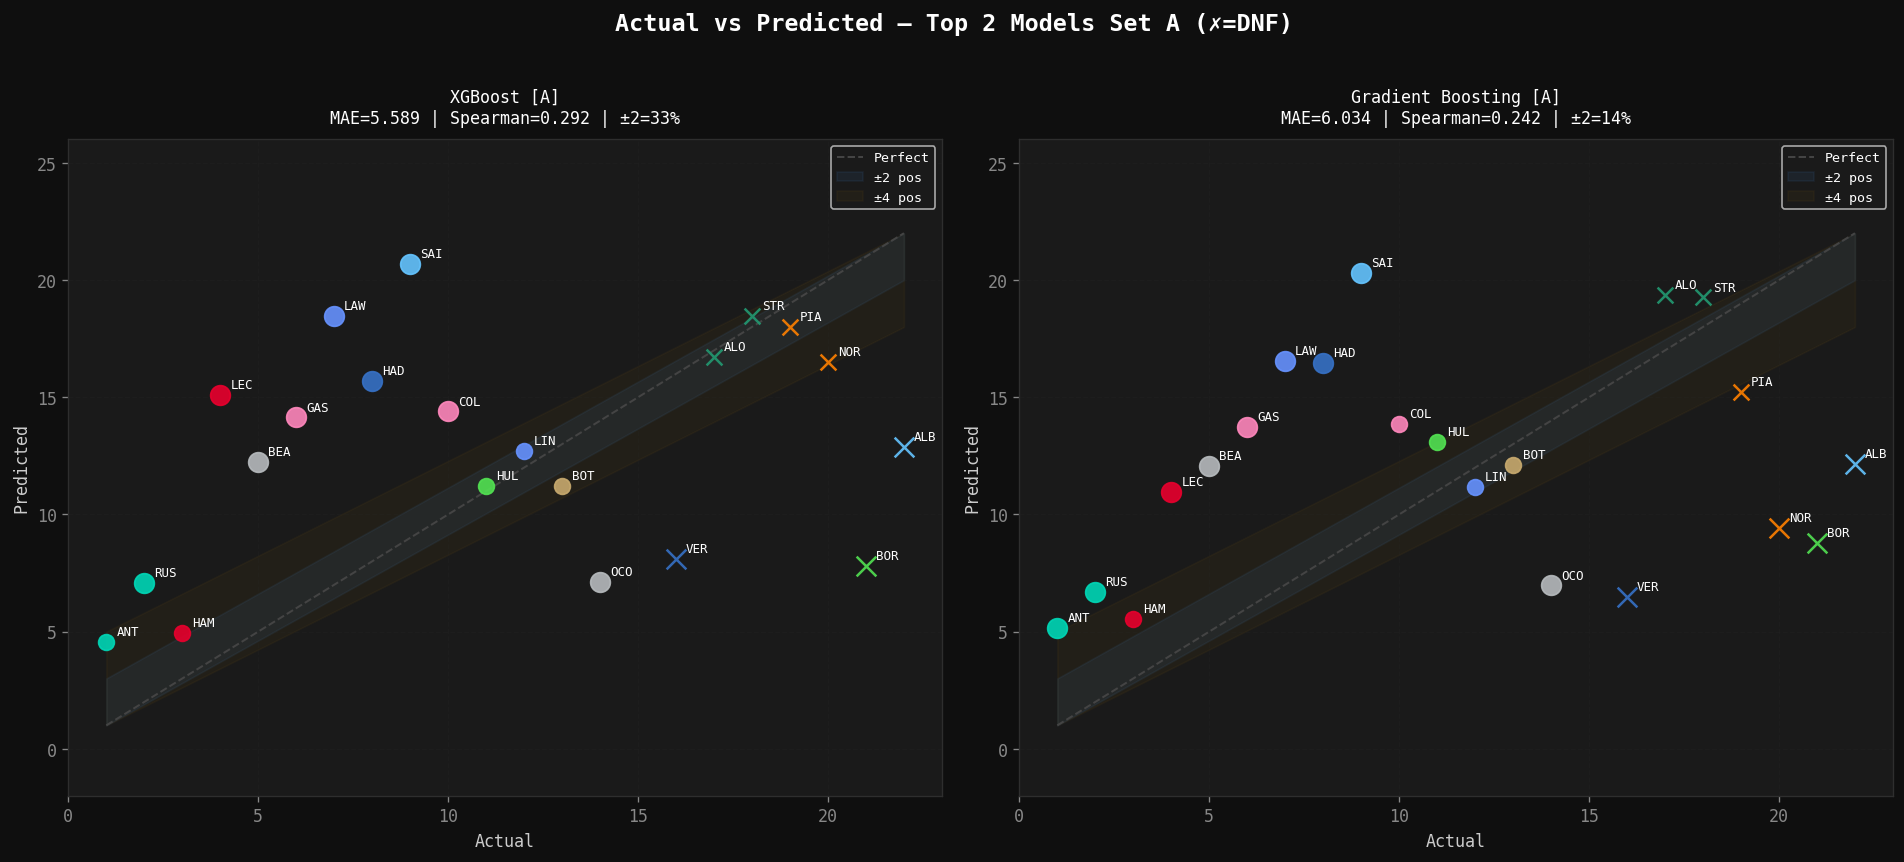

In [14]:
# ── Top 2 models (Set A) ─────────────────────────────────────
top2 = sorted(
    [k for k in results if '[A]' in k],
    key=lambda k: results[k]['Spearman'], reverse=True
)[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f0f0f')

for ax, key in zip(axes, top2):
    preds  = all_preds[key]
    errors = np.abs(preds - y.values)

    for i, driver in enumerate(df_ml['Driver'].values):
        c = driver_color.get(driver,'#888888')
        m = 'x' if df_ml['dnf'].iloc[i] else 'o'
        ax.scatter(y.values[i], preds[i], color=c,
                   s=140 if errors[i]>4 else 90,
                   marker=m, alpha=0.9, zorder=5)
        ax.annotate(driver, (y.values[i], preds[i]),
                    textcoords='offset points', xytext=(6,4),
                    fontsize=7.5, color='white')

    ax.plot([1,22],[1,22],'--',color='#444',linewidth=1.2,label='Perfect')
    ax.fill_between([1,22],[max(1,l-2) for l in [1,22]],
                           [min(22,l+2) for l in [1,22]],
                    alpha=0.07, color='#4a9eff', label='±2 pos')
    ax.fill_between([1,22],[max(1,l-4) for l in [1,22]],
                           [min(22,l+4) for l in [1,22]],
                    alpha=0.04, color='#ffaa00', label='±4 pos')

    r = results[key]
    ax.set_title(f'{key}\nMAE={r["MAE"]} | Spearman={r["Spearman"]} | ±2={r["Within±2"]}',
                 color='white', fontsize=10, pad=10)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
    ax.grid(alpha=0.2); ax.set_xlim(0,23); ax.set_ylim(-2,26)

plt.suptitle('Actual vs Predicted — Top 2 Models Set A (✗=DNF)',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); savefig('07_actual_vs_predicted.png'); plt.show()


  💾 ./figures_ml/08_prediction_error.png


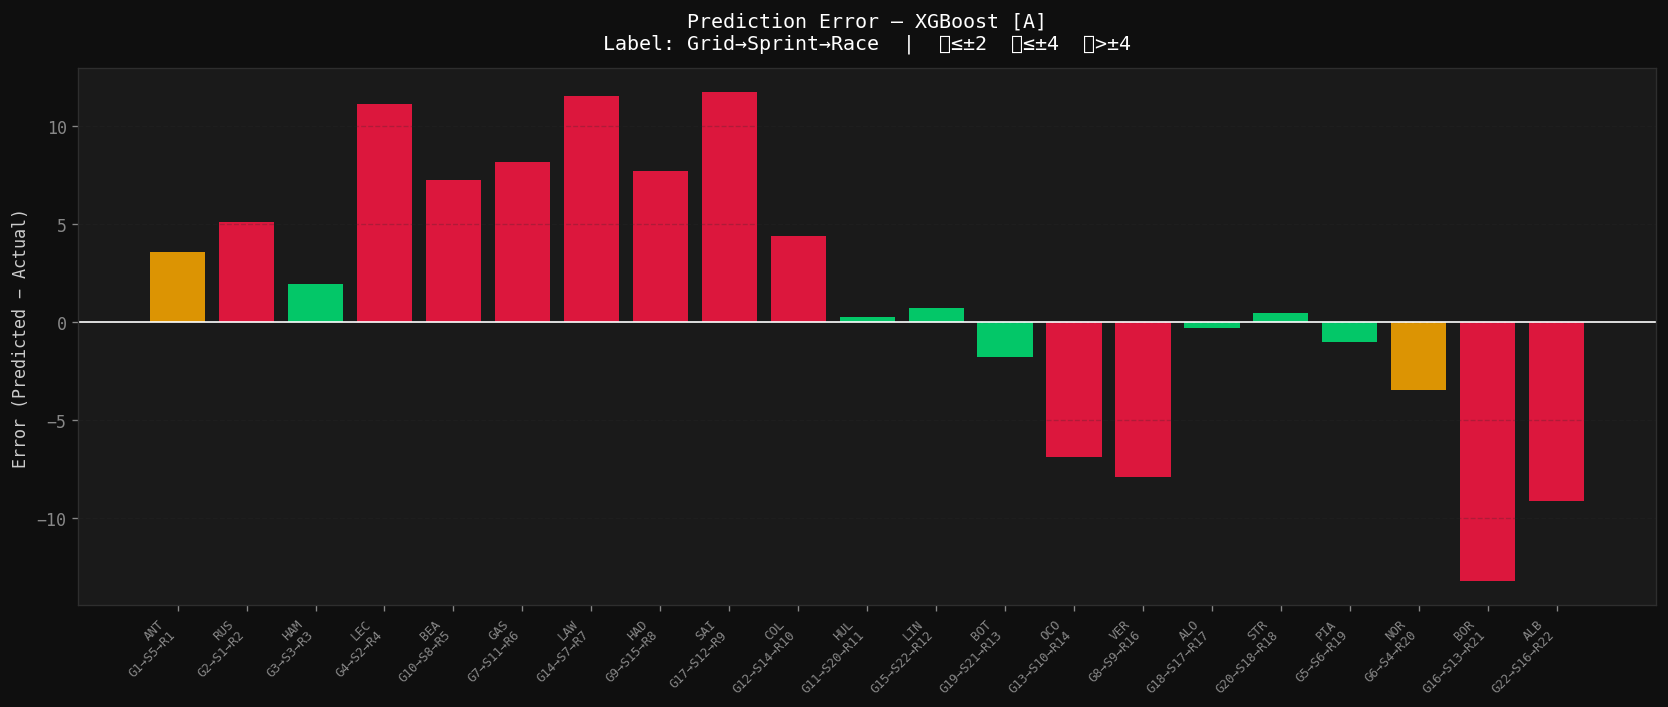


📋 Full prediction table:
Driver            Team  Grid  Sprint  Actual  Predicted  Error
   ANT        Mercedes   1.0     5.0       1        4.6   3.56
   RUS        Mercedes   2.0     1.0       2        7.1   5.09
   HAM         Ferrari   3.0     3.0       3        4.9   1.94
   LEC         Ferrari   4.0     2.0       4       15.1  11.11
   BEA    Haas F1 Team  10.0     8.0       5       12.2   7.24
   GAS          Alpine   7.0    11.0       6       14.1   8.14
   LAW    Racing Bulls  14.0     7.0       7       18.5  11.49
   HAD Red Bull Racing   9.0    15.0       8       15.7   7.68
   SAI        Williams  17.0    12.0       9       20.7  11.69
   COL          Alpine  12.0    14.0      10       14.4   4.39
   HUL            Audi  11.0    20.0      11       11.2   0.23
   LIN    Racing Bulls  15.0    22.0      12       12.7   0.71
   BOT        Cadillac  19.0    21.0      13       11.2  -1.77
   OCO    Haas F1 Team  13.0    10.0      14        7.1  -6.88
   VER Red Bull Racing   8.0 

In [15]:
# ── Error barchart ────────────────────────────────────────────
best_preds = all_preds[best_name]
error_df = pd.DataFrame({
    'Driver'   : df_ml['Driver'].values,
    'Team'     : df_ml['Team'].values,
    'Grid'     : df_ml['grid_pos'].values,
    'Sprint'   : df_ml['sprint_pos'].values,
    'Actual'   : y.values,
    'Predicted': best_preds.round(1),
    'Error'    : (best_preds - y.values).round(2),
    'AbsError' : np.abs(best_preds - y.values).round(2),
}).sort_values('Actual').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f0f')
bar_c = ['#00e676' if abs(e)<=2 else '#ffaa00' if abs(e)<=4 else '#ff1744'
         for e in error_df['Error']]
ax.bar(range(len(error_df)), error_df['Error'], color=bar_c, alpha=0.85)
ax.axhline(0, color='white', linewidth=1)
ax.set_xticks(range(len(error_df)))
ax.set_xticklabels(
    [f"{r.Driver}\nG{int(r.Grid) if pd.notna(r.Grid) else '?'}"
     f"→S{int(r.Sprint) if pd.notna(r.Sprint) else '?'}"
     f"→R{int(r.Actual)}"
     for _, r in error_df.iterrows()],
    fontsize=7.5, rotation=45, ha='right'
)
ax.set_ylabel('Error (Predicted − Actual)')
ax.set_title(f'Prediction Error — {best_name}\n'
             f'Label: Grid→Sprint→Race  |  🟢≤±2  🟡≤±4  🔴>±4',
             color='white', pad=12)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout(); savefig('08_prediction_error.png'); plt.show()

print('\n📋 Full prediction table:')
print(error_df[['Driver','Team','Grid','Sprint','Actual','Predicted','Error']].to_string(index=False))


## 8. 💡 Summary & Export

In [16]:
print('=' * 65)
print('  🏎️  F1 2026 CHINESE GP — ML SUMMARY (SPRINT WEEKEND)')
print('=' * 65)
print()

# Best per set
for set_label in ['A','B']:
    set_keys  = [k for k in results if f'[{set_label}]' in k]
    best_set  = max(set_keys, key=lambda k: results[k]['Spearman'])
    b         = results[best_set]
    feat_note = 'with sprint_pos' if set_label=='A' else 'without sprint_pos'
    print(f'🥇 Best Set {set_label} ({feat_note}): {best_set}')
    print(f'   MAE={b["MAE"]}  Spearman={b["Spearman"]}  ±2={b["Within±2"]}  ±3={b["Within±3"]}')
    print()

# Top features
print('🔑 Top 5 Features (RF, Set A):')
for i,(feat,val) in enumerate(rf_imp.head(5).items(),1):
    print(f'   {i}. {feat:35s}: {val:.3f}')

# Correlations
print()
print('📈 Key correlations with race_pos:')
for feat in ['quali_gap','grid_pos','sprint_pos','sq_gap','sprint_pos_gained']:
    if feat in df_ml.columns:
        r_val = df_ml[[feat,'race_pos']].corr().iloc[0,1]
        print(f'   {feat:30s}: r = {r_val:+.3f}')

# Surprises
print()
print('⚠️  Biggest surprises (model missed most):')
for _, row in error_df.sort_values('AbsError', ascending=False).head(4).iterrows():
    direction = 'better' if row['Error']<0 else 'worse'
    print(f'   {row.Driver:5s} ({row.Team}): '
          f'Grid P{int(row.Grid) if pd.notna(row.Grid) else "?"} → '
          f'Sprint P{int(row.Sprint) if pd.notna(row.Sprint) else "?"} → '
          f'Race P{int(row.Actual)} | pred P{row.Predicted:.0f} '
          f'({row.AbsError:.1f} pos {direction})')

print('\n' + '=' * 65)


  🏎️  F1 2026 CHINESE GP — ML SUMMARY (SPRINT WEEKEND)

🥇 Best Set A (with sprint_pos): XGBoost [A]
   MAE=5.589  Spearman=0.292  ±2=33%  ±3=33%

🥇 Best Set B (without sprint_pos): Linear Regression [B]
   MAE=10.742  Spearman=0.544  ±2=19%  ±3=19%

🔑 Top 5 Features (RF, Set A):
   1. quali_vs_sprint                    : 0.108
   2. quali_s3                           : 0.090
   3. rank_change_sprint_to_quali        : 0.065
   4. quali_s3_vs_field                  : 0.063
   5. sprint_speed                       : 0.060

📈 Key correlations with race_pos:
   quali_gap                     : r = +0.509
   grid_pos                      : r = +0.595
   sprint_pos                    : r = +0.433
   sq_gap                        : r = +0.447
   sprint_pos_gained             : r = +0.228

⚠️  Biggest surprises (model missed most):
   BOR   (Audi): Grid P16 → Sprint P13 → Race P21 | pred P8 (13.2 pos better)
   SAI   (Williams): Grid P17 → Sprint P12 → Race P9 | pred P21 (11.7 pos worse)
   LAW 

  💾 ./figures_ml/09_ml_dashboard.png


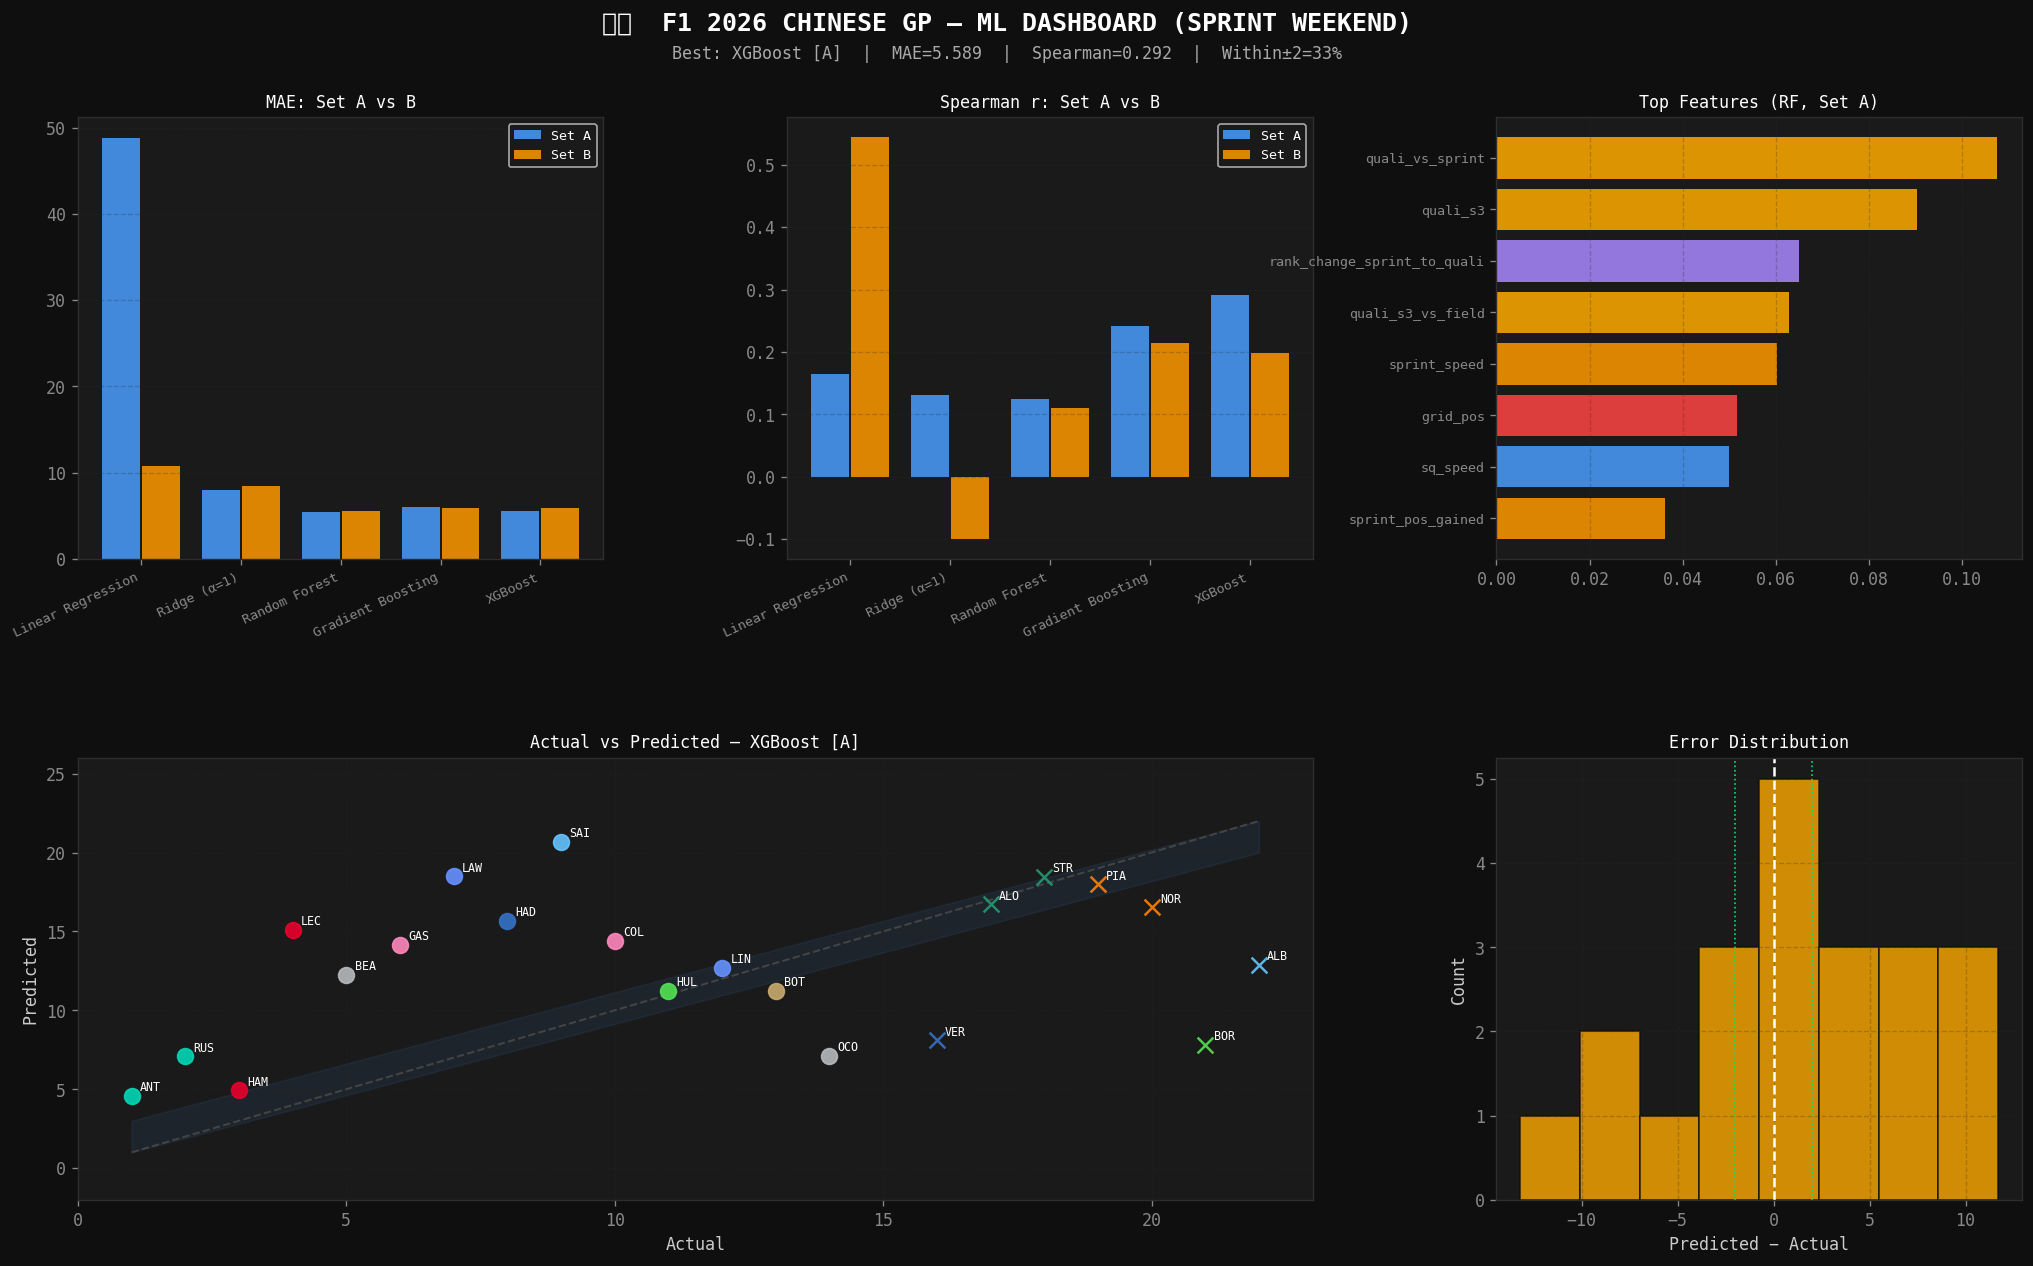

In [17]:
# ── Dashboard ────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0f0f0f')
fig.text(0.5, 0.98, '🏎️  F1 2026 CHINESE GP — ML DASHBOARD (SPRINT WEEKEND)',
         ha='center', va='top', color='white', fontsize=15, fontweight='bold')
b = results[best_name]
fig.text(0.5, 0.955,
         f'Best: {best_name}  |  MAE={b["MAE"]}  |  '
         f'Spearman={b["Spearman"]}  |  Within±2={b["Within±2"]}',
         ha='center', va='top', color='#aaaaaa', fontsize=10)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                      top=0.90, bottom=0.08, left=0.07, right=0.97)

# [0,0] MAE Set A vs B
ax0 = fig.add_subplot(gs[0,0])
x = np.arange(len(model_names))
ax0.bar(x-0.2, mae_A, width=0.38, color='#4a9eff', alpha=0.85, label='Set A')
ax0.bar(x+0.2, mae_B, width=0.38, color='#ff9900', alpha=0.85, label='Set B')
ax0.set_xticks(x); ax0.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
ax0.set_title('MAE: Set A vs B', color='white', fontsize=10)
ax0.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax0.grid(axis='y', alpha=0.25)

# [0,1] Spearman Set A vs B
ax1 = fig.add_subplot(gs[0,1])
ax1.bar(x-0.2, spear_A, width=0.38, color='#4a9eff', alpha=0.85, label='Set A')
ax1.bar(x+0.2, spear_B, width=0.38, color='#ff9900', alpha=0.85, label='Set B')
ax1.set_xticks(x); ax1.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
ax1.set_title('Spearman r: Set A vs B', color='white', fontsize=10)
ax1.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax1.grid(axis='y', alpha=0.25)

# [0,2] RF feature importance top 8
ax2 = fig.add_subplot(gs[0,2])
rf_top = rf_imp.head(8).sort_values()
ax2.barh(range(len(rf_top)), rf_top.values,
         color=[feat_color(f) for f in rf_top.index], alpha=0.85)
ax2.set_yticks(range(len(rf_top)))
ax2.set_yticklabels(rf_top.index, fontsize=8)
ax2.set_title('Top Features (RF, Set A)', color='white', fontsize=10)
ax2.grid(axis='x', alpha=0.25)

# [1,0:2] Actual vs Predicted
ax3 = fig.add_subplot(gs[1,0:2])
preds = all_preds[best_name]
for i, driver in enumerate(df_ml['Driver'].values):
    c = driver_color.get(driver,'#888888')
    m = 'x' if df_ml['dnf'].iloc[i] else 'o'
    ax3.scatter(y.values[i], preds[i], color=c, s=90, marker=m, alpha=0.9, zorder=5)
    ax3.annotate(driver, (y.values[i], preds[i]),
                 textcoords='offset points', xytext=(5,3), fontsize=7, color='white')
ax3.plot([1,22],[1,22],'--',color='#444',linewidth=1.2)
ax3.fill_between([1,22],[max(1,l-2) for l in [1,22]],[min(22,l+2) for l in [1,22]],
                 alpha=0.08, color='#4a9eff')
ax3.set_title(f'Actual vs Predicted — {best_name}', color='white', fontsize=10)
ax3.set_xlabel('Actual'); ax3.set_ylabel('Predicted')
ax3.grid(alpha=0.2); ax3.set_xlim(0,23); ax3.set_ylim(-2,26)

# [1,2] Error histogram
ax4 = fig.add_subplot(gs[1,2])
errs = preds - y.values
ax4.hist(errs, bins=8, color='#ffaa00', alpha=0.8, edgecolor='#0f0f0f')
ax4.axvline(0, color='white', linewidth=1.5, linestyle='--')
ax4.axvline( 2, color='#00e676', linewidth=1, linestyle=':')
ax4.axvline(-2, color='#00e676', linewidth=1, linestyle=':')
ax4.set_title('Error Distribution', color='white', fontsize=10)
ax4.set_xlabel('Predicted − Actual'); ax4.set_ylabel('Count')
ax4.grid(alpha=0.25)

savefig('09_ml_dashboard.png'); plt.show()


In [18]:
# ── Export predictions ────────────────────────────────────────
pred_export = df_ml[['Driver','Team','grid_pos','sprint_pos','race_pos']].copy()
pred_export.columns = ['Driver','Team','Grid','Sprint_Pos','Actual_Race_Pos']

for key, preds in all_preds.items():
    col = key.replace(' ','_').replace('[','').replace(']','').replace('(','').replace(')','').replace('=','')
    pred_export[f'Pred_{col}'] = preds.round(1)
    pred_export[f'Err_{col}']  = (preds - y.values).round(2)

pred_export.to_csv(f'{PROC_DIR}/predictions.csv', index=False)
print('✅ Saved: processed/predictions.csv')
print()
print(pred_export[['Driver','Team','Grid','Sprint_Pos','Actual_Race_Pos',
                   f'Pred_{best_name.replace(" ","_").replace("[","").replace("]","").replace("(","").replace(")","").replace("=","")}']].to_string(index=False))
print()
print(f'📁 Figures saved to ./{FIG_DIR}/:')
import glob
for f in sorted(glob.glob(f'{FIG_DIR}/*.png')):
    print(f'   {f}')


✅ Saved: processed/predictions.csv

Driver            Team  Grid  Sprint_Pos  Actual_Race_Pos  Pred_XGBoost_A
   ANT        Mercedes   1.0         5.0                1             4.6
   RUS        Mercedes   2.0         1.0                2             7.1
   HAM         Ferrari   3.0         3.0                3             4.9
   LEC         Ferrari   4.0         2.0                4            15.1
   BEA    Haas F1 Team  10.0         8.0                5            12.2
   GAS          Alpine   7.0        11.0                6            14.1
   LAW    Racing Bulls  14.0         7.0                7            18.5
   HAD Red Bull Racing   9.0        15.0                8            15.7
   SAI        Williams  17.0        12.0                9            20.7
   COL          Alpine  12.0        14.0               10            14.4
   HUL            Audi  11.0        20.0               11            11.2
   LIN    Racing Bulls  15.0        22.0               12            12.7
  

In [19]:
print(pd.DataFrame(results).T.to_string())
print(f'\nn = {len(y)} drivers')
print(f'Best Set A: {best_name}')

                          MAE      R² Spearman p-value Within±2 Within±3 FeatureSet
Linear Regression [A]   48.75 -440.89    0.165  0.4749       0%       0%          A
Ridge (α=1) [A]          8.02  -0.971    0.131  0.5709      14%      14%          A
Random Forest [A]        5.46  -0.024    0.125  0.5903      29%      33%          A
Gradient Boosting [A]   6.034  -0.186    0.242  0.2915      14%      29%          A
XGBoost [A]             5.589  -0.164    0.292  0.1987      33%      33%          A
Linear Regression [B]  10.742  -4.454    0.544  0.0108      19%      19%          B
Ridge (α=1) [B]         8.467  -1.346     -0.1  0.6663      19%      19%          B
Random Forest [B]       5.554   -0.04     0.11  0.6338      19%      33%          B
Gradient Boosting [B]   5.861  -0.176    0.214  0.3509      19%      38%          B
XGBoost [B]             5.925  -0.328    0.199  0.3879      33%      33%          B

n = 21 drivers
Best Set A: XGBoost [A]
